# Paper Citation Graph — WoS CR → Network → Analysis → Viz

**Pipeline:** WoS `CR` field → three-layer reference matching → directed citation graph → Leiden → cross-country flow → core-share → bridge nodes → interactive viz.

**Outputs** → `output/citation_graph/`


## §0  Configuration & Imports

In [1]:
# §0  Configuration & Imports
import subprocess, sys
try:
    import leidenalg as la
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "leidenalg", "-q"])
    import leidenalg as la
import os, json, re, warnings, time, math
from pathlib import Path
from typing import Optional, List, Dict, Any
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import igraph as ig
import networkx as nx
import plotly.graph_objects as go
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
DATA_CSV   = "data/dataCleanSCIE.csv"
OUTPUT_DIR = Path("output/citation_graph")
FIGS_DIR   = OUTPUT_DIR / "figs"
DIAG_DIR   = OUTPUT_DIR / "diagnostics"
LEIDEN_RES      = 1.0
BETWEENNESS_K   = 5000
SAMPLING_SIZE   = 5000
ROLLING_WINDOW  = 5
BRIDGE_TOP_N    = 100
CN_LABELS_SET = {
    "China", "china", "CN", "CHINA", "Peoples R China", "Peoples R. China",
    "PEOPLES R CHINA", "PRC", "prc", "PR China", "PR CHINA",
}
US_LABELS_SET = {
    "USA", "US", "U.S.A.", "U.S.", "United States", "united states",
    "United States of America", "UNITED STATES", "UNITED STATES OF AMERICA",
}
_CN_UPPER = {x.upper() for x in CN_LABELS_SET}
_US_UPPER = {x.upper() for x in US_LABELS_SET}

for _d in [OUTPUT_DIR, FIGS_DIR, DIAG_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

print(f"Config ready | leidenalg {la.__version__}")
print(f"Output  -> {OUTPUT_DIR.resolve()}")


Config ready | leidenalg 0.11.0
Output  -> /Users/luoyiti/Project/catch-up/output/citation_graph


/Users/luoyiti/Project/catch-up/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## §1  Load Papers

Read WoS CSV, normalise fields, derive `paper_id / year / country2 / doi_norm / author_last / so_norm / vl_str / bp_str`.

In [2]:
# §1  Load Papers
_RE_TRAIL = re.compile(r"[;,.\s]+$")

def normalize_doi(doi_raw) -> Optional[str]:
    if pd.isna(doi_raw) or not str(doi_raw).strip():
        return None
    d = str(doi_raw).strip().lower()
    d = re.sub(r"^https?://(dx\.)?doi\.org/", "", d)
    d = _RE_TRAIL.sub("", d)
    return d if d.startswith("10.") else None

def normalize_source(so_raw) -> str:
    if pd.isna(so_raw) or not str(so_raw).strip():
        return ""
    s = re.sub(r"[^\w\s]", " ", str(so_raw).upper().strip())
    return re.sub(r"\s+", " ", s).strip()

def parse_first_author_lastname(au_raw) -> str:
    if pd.isna(au_raw) or not str(au_raw).strip():
        return ""
    first_author = str(au_raw).strip().split(";")[0].strip()
    return first_author.split(",")[0].strip().upper()

def map_country(c) -> str:
    if pd.isna(c) or not str(c).strip():
        return "Other"
    cu = str(c).strip().upper()
    if cu in _CN_UPPER:
        return "CN"
    if cu in _US_UPPER:
        return "US"
    return "Other"

def load_papers(csv_path: str) -> pd.DataFrame:
    t0 = time.time()
    df = pd.read_csv(csv_path, low_memory=False)
    print(f"Raw CSV: {len(df):,} rows x {df.shape[1]} cols  ({time.time()-t0:.1f}s)")
    df["paper_id"]    = df["UT"].astype(str).str.strip()
    df["year"]        = pd.to_numeric(df["PY"], errors="coerce").astype("Int64")
    df["country2"]    = df["country"].apply(map_country)
    df["doi_norm"]    = df["DI"].apply(normalize_doi)   if "DI" in df.columns else None
    df["author_last"] = df["AU"].apply(parse_first_author_lastname)
    df["so_norm"]     = df["SO"].apply(normalize_source) if "SO" in df.columns else ""
    df["vl_str"]      = (df["VL"].apply(lambda x: "" if pd.isna(x) else str(x).strip())
                         if "VL" in df.columns else "")
    df["bp_str"]      = (df["BP"].apply(lambda x: "" if pd.isna(x) else str(x).strip())
                         if "BP" in df.columns else "")
    df["TC"]          = (pd.to_numeric(df["TC"], errors="coerce").fillna(0).astype(int)
                         if "TC" in df.columns else 0)
    df["TI"]          = df["TI"].fillna("").astype(str) if "TI" in df.columns else ""
    print(f"  year range  : {df['year'].min()} - {df['year'].max()}")
    print(f"  country2    : {df['country2'].value_counts().to_dict()}")
    print(f"  doi non-null: {df['doi_norm'].notna().sum():,} / {len(df):,}")
    cr_nn = df["CR"].notna().sum() if "CR" in df.columns else 0
    print(f"  CR non-null : {cr_nn:,}")
    return df

df_papers = load_papers(DATA_CSV)
N_PAPERS  = len(df_papers)
print(f"\nTotal papers N = {N_PAPERS:,}")


Raw CSV: 25,794 rows x 41 cols  (0.7s)
  year range  : 1990 - 2026
  country2    : {'Other': 16728, 'CN': 5687, 'US': 3379}
  doi non-null: 24,018 / 25,794
  CR non-null : 25,160

Total papers N = 25,794


## §2  CR Parsing Functions

Parse each WoS `CR` reference string into structured fields for three-layer matching (DOI / strict bibkey / loose bibkey).

In [3]:
# §2  CR Parsing Functions
_RE_DOI  = re.compile(r"\b(10\.\d{4,9}/[-._;()/:A-Za-z0-9#+]+)", re.IGNORECASE)
_RE_YEAR = re.compile(r"\b(1[89]\d{2}|20[012]\d)\b")
_RE_VOL  = re.compile(r"\bV(\d+)\b", re.IGNORECASE)
_RE_PAGE = re.compile(r"\bP(\d+)\b", re.IGNORECASE)

def parse_cr_list(cr_str) -> List[str]:
    if pd.isna(cr_str) or not str(cr_str).strip():
        return []
    return [r.strip() for r in str(cr_str).split(";") if r.strip()]

def extract_ref_fields(ref_raw: str) -> Dict[str, Any]:
    out = dict(doi_ref_norm=None, author_last_ref="", year_ref=None,
               so_ref_norm="", vl_ref="", bp_ref="",
               key_strict_ref=None, key_loose_ref=None)
    if not ref_raw or not ref_raw.strip():
        return out
    ref = ref_raw.strip()
    # 1) DOI
    doi_m = _RE_DOI.search(ref)
    if doi_m:
        out["doi_ref_norm"] = _RE_TRAIL.sub("", doi_m.group(1)).lower()
    # 2) Comma-split
    parts = [p.strip() for p in ref.split(",")]
    # 3) Author last name
    if parts and parts[0].strip():
        tokens = parts[0].strip().upper().split()
        out["author_last_ref"] = tokens[0] if len(tokens) == 1 else " ".join(tokens[:-1])
    # 4) Year
    yr_m = _RE_YEAR.search(ref)
    if yr_m:
        out["year_ref"] = int(yr_m.group(1))
    # 5) Source: first non-empty field after year field
    if out["year_ref"]:
        yr_str = str(out["year_ref"])
        for idx, p in enumerate(parts):
            if yr_str in p and idx + 1 < len(parts):
                cand = parts[idx + 1].strip()
                if cand:
                    out["so_ref_norm"] = normalize_source(cand)
                break
    # 6) Volume + page
    vl_m = _RE_VOL.search(ref)
    if vl_m:
        out["vl_ref"] = vl_m.group(1)
    pg_m = _RE_PAGE.search(ref)
    if pg_m:
        out["bp_ref"] = pg_m.group(1)
    # 7) Bibkeys
    au, yr, so = out["author_last_ref"], out["year_ref"], out["so_ref_norm"]
    vl, bp     = out["vl_ref"], out["bp_ref"]
    if au and yr and so and vl and bp:
        out["key_strict_ref"] = f"{au}|{yr}|{so}|V{vl}|P{bp}"
    if au and yr and so:
        out["key_loose_ref"] = f"{au}|{yr}|{so}"
    return out

# Sanity check
_test = "CURRIE LA, 1968, ANAL CHEM, V40, P586, DOI 10.1021/ac60259a007"
_flds = extract_ref_fields(_test)
print("Sanity check:", _test)
for _k, _v in _flds.items():
    if _v:
        print(f"  {_k}: {_v}")


Sanity check: CURRIE LA, 1968, ANAL CHEM, V40, P586, DOI 10.1021/ac60259a007
  doi_ref_norm: 10.1021/ac60259a007
  author_last_ref: CURRIE
  year_ref: 1968
  so_ref_norm: ANAL CHEM
  vl_ref: 40
  bp_ref: 586
  key_strict_ref: CURRIE|1968|ANAL CHEM|V40|P586
  key_loose_ref: CURRIE|1968|ANAL CHEM


## §3  Build Reference Index

Construct lookups `idx_doi`, `idx_strict`, `idx_loose` over all sample papers.

In [4]:
# §3  Build Reference Index

def build_reference_index(df_papers: pd.DataFrame):
    idx_doi    = {}
    idx_strict = {}
    idx_loose  = {}
    idx_attrs  = {}
    for row in tqdm(df_papers.itertuples(), total=len(df_papers), desc="Building index"):
        pid = row.paper_id
        idx_attrs[pid] = {"vl": row.vl_str, "bp": row.bp_str}
        doi = row.doi_norm
        if doi and not pd.isna(doi):
            if doi in idx_doi:
                idx_doi[doi] = "__ambiguous__"
            else:
                idx_doi[doi] = pid
        au = row.author_last
        yr = row.year
        so = row.so_norm
        vl = row.vl_str
        bp = row.bp_str
        if au and pd.notna(yr) and so and vl and bp:
            key_s = f"{au}|{yr}|{so}|V{vl}|P{bp}"
            if key_s in idx_strict:
                idx_strict[key_s] = "__ambiguous__"
            else:
                idx_strict[key_s] = pid
        if au and pd.notna(yr) and so:
            key_l = f"{au}|{yr}|{so}"
            if key_l not in idx_loose:
                idx_loose[key_l] = []
            idx_loose[key_l].append(pid)
    n_doi_ok    = sum(1 for v in idx_doi.values()    if v != "__ambiguous__")
    n_strict_ok = sum(1 for v in idx_strict.values() if v != "__ambiguous__")
    n_loose_u   = sum(1 for v in idx_loose.values()  if len(v) == 1)
    print(f"Index: DOI {len(idx_doi):,} keys ({n_doi_ok:,} unambiguous) | "
          f"Strict {len(idx_strict):,} keys ({n_strict_ok:,} unambiguous) | "
          f"Loose {len(idx_loose):,} keys ({n_loose_u:,} single-match)")
    return idx_doi, idx_strict, idx_loose, idx_attrs

idx_doi, idx_strict, idx_loose, idx_attrs = build_reference_index(df_papers)


Building index: 100%|██████████| 25794/25794 [00:00<00:00, 279119.61it/s]

Index: DOI 24,014 keys (24,010 unambiguous) | Strict 17,007 keys (17,007 unambiguous) | Loose 24,187 keys (23,041 single-match)


## §4  Match Reference -> UT  |  §5  Build Directed Edges

`match_reference_to_ut` tries DOI > strict bibkey > loose bibkey with volume/page disambiguation.  `build_edges` iterates over every paper's CR field and writes edge list + diagnostics.

Building edges: 100%|██████████| 25794/25794 [00:03<00:00, 6705.92it/s]


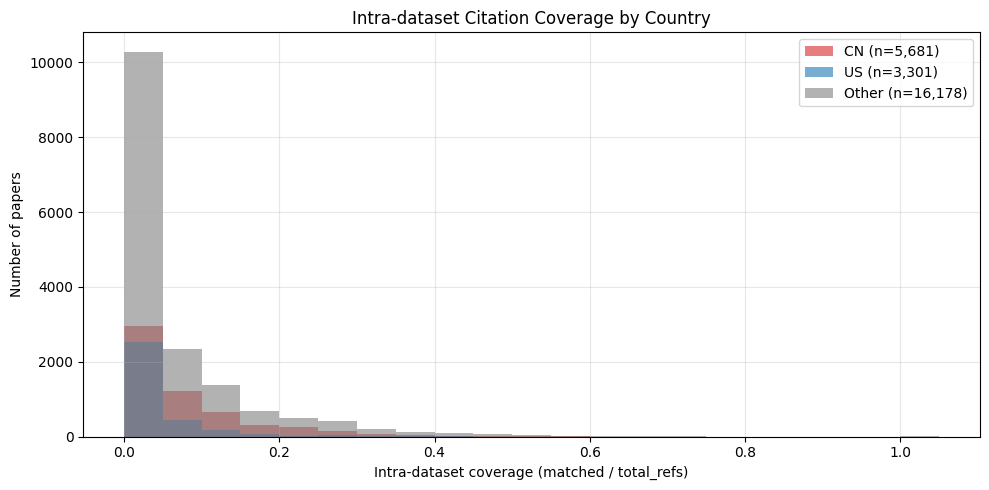

Edges built     : 49,396
Match counts    : {'doi': 48979, 'strict': 74, 'loose': 374, 'none': 754157}
Match rate      : 0.0615
Time violations : 36 (0.07%)


In [5]:
# §4  match_reference_to_ut  |  §5  build_edges  + Diagnostics
_PRIORITY = {"doi": 0, "strict": 1, "loose": 2}

def match_reference_to_ut(ref_fields, idx_doi, idx_strict, idx_loose, idx_attrs):
    doi = ref_fields.get("doi_ref_norm")
    if doi:
        hit = idx_doi.get(doi)
        if hit and hit != "__ambiguous__":
            return hit, "doi"
    key_s = ref_fields.get("key_strict_ref")
    if key_s:
        hit = idx_strict.get(key_s)
        if hit and hit != "__ambiguous__":
            return hit, "strict"
    key_l = ref_fields.get("key_loose_ref")
    if key_l:
        candidates = idx_loose.get(key_l, [])
        if len(candidates) == 1:
            return candidates[0], "loose"
        elif len(candidates) > 1:
            vl_r = ref_fields.get("vl_ref", "")
            bp_r = ref_fields.get("bp_ref", "")
            if vl_r or bp_r:
                matched = [cid for cid in candidates
                           if ((not vl_r) or idx_attrs.get(cid, {}).get("vl", "") == vl_r)
                           and ((not bp_r) or idx_attrs.get(cid, {}).get("bp", "") == bp_r)]
                if len(matched) == 1:
                    return matched[0], "loose"
            return None, None
    return None, None

def build_edges(df_papers, idx_doi, idx_strict, idx_loose, idx_attrs):
    valid_ids  = set(df_papers["paper_id"].values)
    paper_meta = {row.paper_id: {"year": row.year, "country2": row.country2}
                  for row in df_papers.itertuples()}
    edge_records   = []
    coverage_records = []
    match_counts   = {"doi": 0, "strict": 0, "loose": 0, "none": 0}
    for row in tqdm(df_papers.itertuples(), total=len(df_papers), desc="Building edges"):
        src_id  = row.paper_id
        cr_str  = getattr(row, "CR", None)
        refs    = parse_cr_list(cr_str)
        total_refs = len(refs)
        matched = 0
        seen_dst = {}
        for ref_raw in refs:
            flds  = extract_ref_fields(ref_raw)
            dst_id, mtype = match_reference_to_ut(
                flds, idx_doi, idx_strict, idx_loose, idx_attrs)
            if dst_id is None or dst_id == src_id or dst_id not in valid_ids:
                match_counts["none"] += 1
                continue
            match_counts[mtype] += 1
            matched += 1
            if dst_id not in seen_dst:
                seen_dst[dst_id] = mtype
            elif _PRIORITY[mtype] < _PRIORITY.get(seen_dst[dst_id], 99):
                seen_dst[dst_id] = mtype
        src_meta = paper_meta[src_id]
        for dst_id, mtype in seen_dst.items():
            dst_meta = paper_meta[dst_id]
            edge_records.append({
                "src": src_id, "dst": dst_id, "match_type": mtype,
                "year_src": src_meta["year"], "year_dst": dst_meta["year"],
                "country_src": src_meta["country2"], "country_dst": dst_meta["country2"],
            })
        coverage_records.append({
            "paper_id": src_id, "country2": row.country2,
            "total_refs": total_refs, "matched_refs": matched,
            "coverage": matched / total_refs if total_refs > 0 else float("nan"),
        })
    _cols = ["src", "dst", "match_type", "year_src", "year_dst", "country_src", "country_dst"]
    edges_df    = (pd.DataFrame(edge_records) if edge_records else pd.DataFrame(columns=_cols))
    coverage_df = pd.DataFrame(coverage_records)
    # Time-violation diagnostics
    if len(edges_df):
        yr_s = pd.to_numeric(edges_df["year_src"], errors="coerce")
        yr_d = pd.to_numeric(edges_df["year_dst"], errors="coerce")
        tv_mask = (yr_d > yr_s) & yr_s.notna() & yr_d.notna()
        tv_count = int(tv_mask.sum())
        tv_rate  = round(tv_count / len(edges_df), 4)
    else:
        tv_count, tv_rate = 0, 0.0
    tv_stats = {"time_violation_count": tv_count, "time_violation_rate": tv_rate,
                "total_edges": len(edges_df)}
    with open(DIAG_DIR / "time_violation_stats.json", "w") as f:
        json.dump(tv_stats, f, indent=2)
    total_attempts = sum(match_counts.values())
    pd.DataFrame([
        {"match_type": k, "count": v,
         "rate": round(v / total_attempts, 4) if total_attempts else 0}
        for k, v in match_counts.items()
    ]).to_csv(DIAG_DIR / "match_rate_by_type.csv", index=False)
    # Coverage histogram by country2
    cov_data = coverage_df[coverage_df["total_refs"] > 0]
    bins     = [i * 0.05 for i in range(22)]
    fig, ax  = plt.subplots(figsize=(10, 5))
    for grp, col in {"CN": "tab:red", "US": "tab:blue", "Other": "tab:grey"}.items():
        sub = cov_data[cov_data["country2"] == grp]["coverage"].dropna()
        if len(sub):
            ax.hist(sub, bins=bins, alpha=0.6, color=col,
                    label=f"{grp} (n={len(sub):,})", edgecolor="none")
    ax.set_xlabel("Intra-dataset coverage (matched / total_refs)")
    ax.set_ylabel("Number of papers")
    ax.set_title("Intra-dataset Citation Coverage by Country")
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fig.savefig(DIAG_DIR / "intra_dataset_coverage_hist.png", dpi=150)
    plt.show()
    total_ok = match_counts["doi"] + match_counts["strict"] + match_counts["loose"]
    print(f"Edges built     : {len(edges_df):,}")
    print(f"Match counts    : {match_counts}")
    if total_attempts:
        print(f"Match rate      : {total_ok / total_attempts:.4f}")
    print(f"Time violations : {tv_count:,} ({tv_rate:.2%})")
    return edges_df, coverage_df, match_counts

edges_df, coverage_df, match_counts = build_edges(
    df_papers, idx_doi, idx_strict, idx_loose, idx_attrs)


## §6  Build igraph, Leiden Community Detection, Node Metrics

- Directed `g_dir` for in/out-degree and PageRank
- `g_und = g_dir.as_undirected(combine_edges='sum')` for Leiden, coreness, betweenness

In [6]:
# §6  Build igraph  + Leiden Community Detection  + Node Metrics
pid_list   = df_papers["paper_id"].tolist()
pid_to_idx = {pid: i for i, pid in enumerate(pid_list)}

t0 = time.time()
g_dir = ig.Graph(n=N_PAPERS, directed=True)
g_dir.vs["name"] = pid_list
if len(edges_df):
    src_idx = [pid_to_idx[p] for p in edges_df["src"]]
    dst_idx = [pid_to_idx[p] for p in edges_df["dst"]]
    g_dir.add_edges(list(zip(src_idx, dst_idx)))
    g_dir.es["weight"] = [1] * len(edges_df)
print(f"Directed   graph: V={g_dir.vcount():,}  E={g_dir.ecount():,}  ({time.time()-t0:.1f}s)")

g_und = g_dir.as_undirected(combine_edges="sum")
if g_und.ecount() and not g_und.is_weighted():
    g_und.es["weight"] = [1.0] * g_und.ecount()
print(f"Undirected graph: V={g_und.vcount():,}  E={g_und.ecount():,}")

def run_leiden(g, resolution=1.0, seed=42):
    weights = g.es["weight"] if g.ecount() and g.is_weighted() else None
    part = la.find_partition(
        g, la.RBConfigurationVertexPartition,
        weights=weights, resolution_parameter=resolution, seed=seed)
    mem = list(part.membership)
    mod = g.modularity(mem, weights=weights)
    print(f"Leiden: {len(set(mem)):,} communities, modularity={mod:.4f}")
    return mem, mod

def compute_node_metrics(g_dir, g_und, n_nodes, betweenness_k=5000, seed=42):
    in_deg  = g_dir.indegree()
    out_deg = g_dir.outdegree()
    pgrank  = g_dir.pagerank(directed=True, damping=0.85, weights=None)
    coreness = g_und.coreness()
    if n_nodes <= betweenness_k:
        betw = g_und.betweenness(directed=False, weights=None)
        betw_method = "exact"
    else:
        rng  = np.random.RandomState(seed)
        sids = rng.choice(n_nodes, size=betweenness_k, replace=False).tolist()
        bp   = g_und.betweenness(vertices=sids, directed=False, weights=None)
        betw = [float("nan")] * n_nodes
        for vi, bv in zip(sids, bp):
            betw[vi] = bv
        betw_method = f"sampled_{betweenness_k}"
    print(f"Betweenness: {betw_method}")
    return in_deg, out_deg, pgrank, coreness, betw, betw_method

membership, modularity = run_leiden(g_und, resolution=LEIDEN_RES, seed=SEED)
in_deg, out_deg, pgrank, coreness, betw, betw_method = compute_node_metrics(
    g_dir, g_und, N_PAPERS, betweenness_k=BETWEENNESS_K, seed=SEED)

nodes_df = pd.DataFrame({
    "paper_id":    pid_list,
    "year":        df_papers["year"].values,
    "country2":    df_papers["country2"].values,
    "TC":          df_papers["TC"].values,
    "TI":          df_papers["TI"].values,
    "community_id": membership,
    "in_deg":      in_deg,
    "out_deg":     out_deg,
    "pagerank":    pgrank,
    "betweenness": betw,
    "coreness":    coreness,
})
_iso = int(((nodes_df["in_deg"] == 0) & (nodes_df["out_deg"] == 0)).sum())
print(f"in_deg  max={nodes_df['in_deg'].max()}  mean={nodes_df['in_deg'].mean():.2f}")
print(f"out_deg max={nodes_df['out_deg'].max()}  mean={nodes_df['out_deg'].mean():.2f}")
print(f"Isolated (in==out==0): {_iso:,}  |  Coreness range: {min(coreness)}-{max(coreness)}")


Directed   graph: V=25,794  E=49,396  (0.0s)
Undirected graph: V=25,794  E=49,351
Leiden: 8,789 communities, modularity=0.8302
Betweenness: sampled_5000
in_deg  max=177  mean=1.92
out_deg max=63  mean=1.92
Isolated (in==out==0): 8,020  |  Coreness range: 0-15


## §7  Export Parquet & Histograms

Save `edges.parquet`, `nodes.parquet`, `communities.parquet`, `degree_hist.png`, `community_size_hist.png`.

Saved: edges.parquet (49,396 rows), nodes.parquet (25,794 rows), communities.parquet


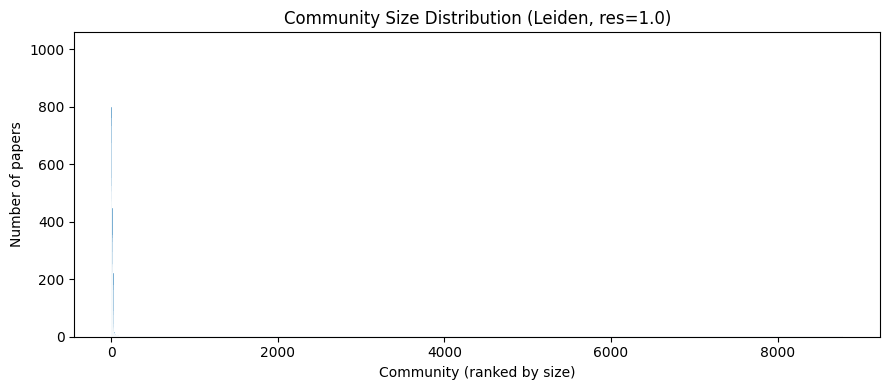

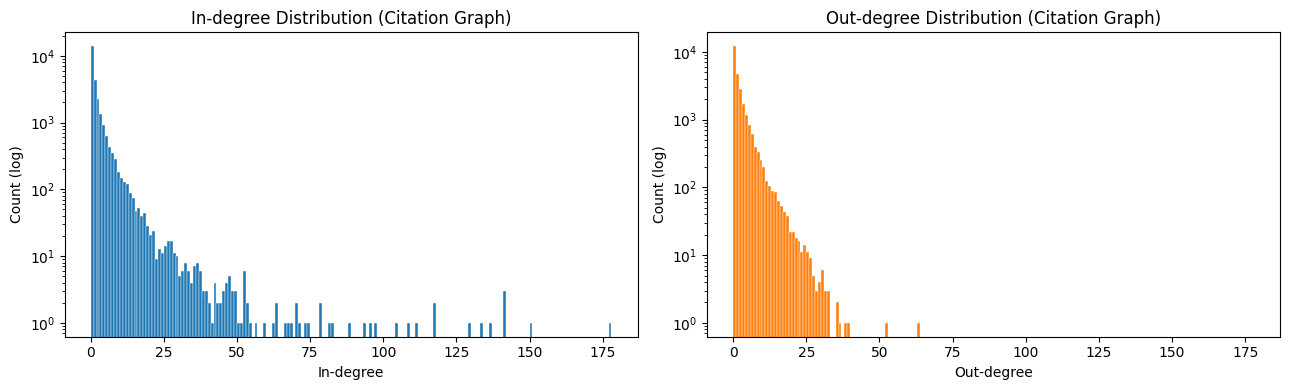

Communities: 8789  Modularity: 0.8302  Largest: 3.91%


In [7]:
# §7  Export Parquet & Histograms
edges_df.to_parquet(OUTPUT_DIR / "edges.parquet",       index=False)
nodes_df.to_parquet(OUTPUT_DIR / "nodes.parquet",       index=False)
nodes_df[["paper_id", "community_id"]].to_parquet(OUTPUT_DIR / "communities.parquet", index=False)
print(f"Saved: edges.parquet ({len(edges_df):,} rows), "
      f"nodes.parquet ({len(nodes_df):,} rows), communities.parquet")

# Community size histogram
comm_sizes = pd.Series(membership).value_counts().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(comm_sizes)), comm_sizes.values, width=1.0, edgecolor="white", linewidth=0.3)
ax.set_xlabel("Community (ranked by size)")
ax.set_ylabel("Number of papers")
ax.set_title(f"Community Size Distribution (Leiden, res={LEIDEN_RES})")
plt.tight_layout()
fig.savefig(FIGS_DIR / "community_size_hist.png", dpi=150)
plt.show()

# Degree histogram
in_d  = np.array(in_deg,  dtype=float)
out_d = np.array(out_deg, dtype=float)
max_d = max(int(in_d.max()), int(out_d.max()), 1)
_bins = range(0, min(max_d + 2, 200))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(in_d,  bins=_bins, color="tab:blue",   edgecolor="white", linewidth=0.3)
axes[0].set_xlabel("In-degree"); axes[0].set_ylabel("Count (log)"); axes[0].set_yscale("log")
axes[0].set_title("In-degree Distribution (Citation Graph)")
axes[1].hist(out_d, bins=_bins, color="tab:orange", edgecolor="white", linewidth=0.3)
axes[1].set_xlabel("Out-degree"); axes[1].set_ylabel("Count (log)"); axes[1].set_yscale("log")
axes[1].set_title("Out-degree Distribution (Citation Graph)")
plt.tight_layout()
fig.savefig(FIGS_DIR / "degree_hist.png", dpi=150)
plt.show()

comm_stats = {
    "n_communities":         int(len(comm_sizes)),
    "modularity":            round(float(modularity), 4),
    "largest_community_frac": round(float(comm_sizes.iloc[0] / N_PAPERS), 4),
    "betweenness_method":    betw_method,
    "top5_comm_sizes": {int(k): int(v) for k, v in comm_sizes.head(5).items()},
}
print(f"Communities: {comm_stats['n_communities']}  "
      f"Modularity: {comm_stats['modularity']}  "
      f"Largest: {comm_stats['largest_community_frac']:.2%}")


## §8  Cross-Country Flow Matrix & Assortativity

Directed 3×3 flow matrix (row=citing, col=cited). Key metrics: CN→US, US→CN, net flow, cross-country ratio, assortativity.

CN->US=1,717  US->CN=288  net=+1,429  cross_ratio=0.2809


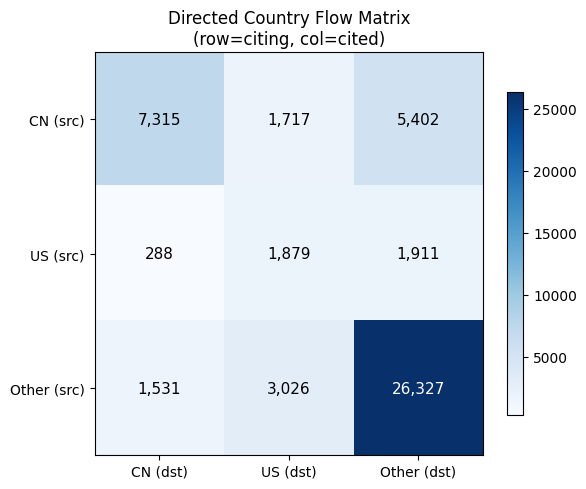

Assortativity (country) = 0.4431  [full]


In [8]:
# §8  Cross-Country Flow Matrix & Assortativity
COUNTRY_ORDER = ["CN", "US", "Other"]
_c2i = {"CN": 0, "US": 1, "Other": 2}

def compute_flow_matrix(edges_df, country_order, c2i):
    n   = len(country_order)
    mat = np.zeros((n, n), dtype=int)
    for row in edges_df.itertuples():
        mat[c2i.get(row.country_src, 2), c2i.get(row.country_dst, 2)] += 1
    return mat

flow_mat = (compute_flow_matrix(edges_df, COUNTRY_ORDER, _c2i)
            if len(edges_df) else np.zeros((3, 3), dtype=int))
total_flow          = int(flow_mat.sum())
cn_us               = int(flow_mat[0, 1])
us_cn               = int(flow_mat[1, 0])
net_flow            = cn_us - us_cn
diag                = int(np.diag(flow_mat).sum())
cross_country_ratio = round((total_flow - diag) / total_flow, 4) if total_flow else 0.0
print(f"CN->US={cn_us:,}  US->CN={us_cn:,}  net={net_flow:+,}  "
      f"cross_ratio={cross_country_ratio:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(flow_mat, aspect="auto", cmap="Blues")
ax.set_xticks(range(3)); ax.set_xticklabels(["CN (dst)", "US (dst)", "Other (dst)"])
ax.set_yticks(range(3)); ax.set_yticklabels(["CN (src)", "US (src)", "Other (src)"])
ax.set_title("Directed Country Flow Matrix\n(row=citing, col=cited)")
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{flow_mat[i, j]:,}", ha="center", va="center", fontsize=11,
                color="white" if flow_mat[i, j] > flow_mat.max() * 0.55 else "black")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
fig.savefig(FIGS_DIR / "country_flow_heatmap.png", dpi=150)
plt.show()

# Country assortativity
MAX_NX     = 50_000
edge_sample = (edges_df if len(edges_df) <= MAX_NX
               else edges_df.sample(n=MAX_NX, random_state=SEED))
assort_note = "full" if len(edges_df) <= MAX_NX else f"sampled_{MAX_NX}"
Gnx = nx.Graph()
for row in edge_sample.itertuples():
    si = pid_to_idx.get(row.src, -1)
    di = pid_to_idx.get(row.dst, -1)
    if si >= 0 and di >= 0:
        Gnx.add_edge(si, di)
for nid in Gnx.nodes():
    Gnx.nodes[nid]["country"] = nodes_df.iloc[nid]["country2"]
try:
    assortativity_country = round(
        float(nx.attribute_assortativity_coefficient(Gnx, "country")), 4)
except Exception:
    assortativity_country = None
print(f"Assortativity (country) = {assortativity_country}  [{assort_note}]")

flow_metrics = {
    "flow_matrix": {
        f"{COUNTRY_ORDER[i]}->{COUNTRY_ORDER[j]}": int(flow_mat[i, j])
        for i in range(3) for j in range(3)
    },
    "CN_to_US": cn_us, "US_to_CN": us_cn, "net_flow_CN_US": net_flow,
    "cross_country_ratio": cross_country_ratio,
    "assortativity_country": assortativity_country,
    "assortativity_note": assort_note,
}


## §9  Core Share Over Time

CN / US share among high-coreness nodes by year.  Threshold = 75th-percentile coreness (fallback 90th if zero).  Rolling window = 5 years.

High-core threshold >= 3: 8,610 (33.4%)


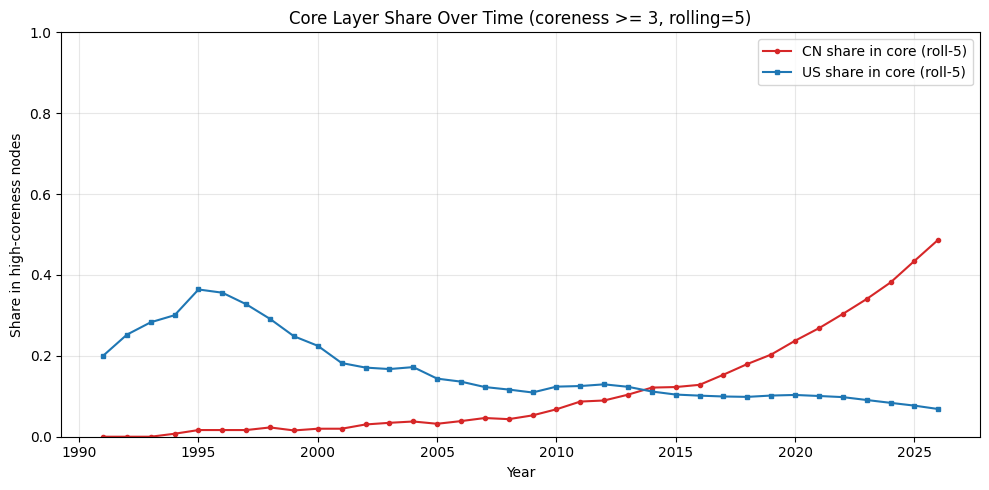

In [9]:
# §9  Core Share Over Time

def core_share_over_time(nodes_df, figs_dir, rolling_w=5):
    if nodes_df["year"].isna().all():
        print("No year data; skipping.")
        return [], None, 0
    q75 = int(nodes_df["coreness"].quantile(0.75))
    if q75 == 0:
        q75 = int(nodes_df["coreness"].quantile(0.90))
    if q75 == 0:
        q75 = 1
    high_core = nodes_df[nodes_df["coreness"] >= q75].copy()
    print(f"High-core threshold >= {q75}: {len(high_core):,} ({len(high_core)/len(nodes_df):.1%})")
    yearly = (high_core.groupby("year")["country2"]
              .value_counts().unstack(fill_value=0))
    for c in ["CN", "US", "Other"]:
        if c not in yearly.columns:
            yearly[c] = 0
    yearly = yearly.reset_index()
    yearly["total"]    = yearly[["CN", "US", "Other"]].sum(axis=1)
    yearly["CN_share"] = yearly["CN"] / yearly["total"].replace(0, float("nan"))
    yearly["US_share"] = yearly["US"] / yearly["total"].replace(0, float("nan"))
    yearly = (yearly[pd.to_numeric(yearly["year"], errors="coerce") > 1900]
              .sort_values("year"))
    yearly["CN_share_roll"] = yearly["CN_share"].rolling(rolling_w, min_periods=2).mean()
    yearly["US_share_roll"] = yearly["US_share"].rolling(rolling_w, min_periods=2).mean()
    yy = yearly["year"].astype(float)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(yy, yearly["CN_share_roll"], "o-", markersize=3, color="tab:red",
            label=f"CN share in core (roll-{rolling_w})")
    ax.plot(yy, yearly["US_share_roll"], "s-", markersize=3, color="tab:blue",
            label=f"US share in core (roll-{rolling_w})")
    ax.set_xlabel("Year"); ax.set_ylabel("Share in high-coreness nodes")
    ax.set_title(f"Core Layer Share Over Time (coreness >= {q75}, rolling={rolling_w})")
    ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylim(0, 1)
    plt.tight_layout()
    fig.savefig(figs_dir / "core_share_over_time.png", dpi=150)
    plt.show()
    records = yearly[["year", "CN", "US", "Other", "total",
                       "CN_share_roll", "US_share_roll"]].to_dict("records")
    return records, q75, len(high_core)

core_ts, core_threshold, core_size = core_share_over_time(
    nodes_df, FIGS_DIR, rolling_w=ROLLING_WINDOW)


## §10  Bridge Nodes

Rank by betweenness + cross-country neighbor ratio.  Export top-100 to `bridge_nodes.csv`.

In [10]:
# §10  Bridge Nodes

def compute_cross_country_neighbor_ratio(g_und, nodes_df):
    country_arr = nodes_df["country2"].values
    ratios = []
    for i in range(g_und.vcount()):
        nbrs = g_und.neighbors(i)
        if not nbrs:
            ratios.append(float("nan"))
            continue
        cross = sum(1 for nb in nbrs if country_arr[nb] != country_arr[i])
        ratios.append(cross / len(nbrs))
    return ratios

print("Computing cross-country neighbor ratios ...")
cc_ratios = compute_cross_country_neighbor_ratio(g_und, nodes_df)
nodes_df["cross_country_ratio"] = cc_ratios

_btw_s    = pd.Series(betw,      dtype=float)
_ccr_s    = pd.Series(cc_ratios, dtype=float)
_combined = _btw_s.fillna(0).rank(pct=True) + _ccr_s.fillna(0).rank(pct=True)
top_idx   = _combined.nlargest(BRIDGE_TOP_N).index.tolist()
bridge_df = (
    nodes_df.iloc[top_idx][["paper_id", "TI", "year", "country2",
                             "betweenness", "cross_country_ratio",
                             "pagerank", "in_deg", "out_deg", "coreness"]]
    .copy().reset_index(drop=True)
    .rename(columns={"paper_id": "UT", "TI": "title"})
)
bridge_df.to_csv(OUTPUT_DIR / "bridge_nodes.csv", index=False)
print(f"Saved bridge_nodes.csv (top {BRIDGE_TOP_N})")
print(bridge_df.head(5)[["UT", "year", "country2",
                          "betweenness", "cross_country_ratio"]].to_string(index=False))


Computing cross-country neighbor ratios ...
Saved bridge_nodes.csv (top 100)
                 UT  year country2   betweenness  cross_country_ratio
WOS:000587156500001  2020       US 545483.481374                  1.0
WOS:000234770600005  2006       US 453347.316300                  1.0
WOS:000370109200010  2016       US 185091.073835                  1.0
WOS:000959966300001  2023    Other 173025.475608                  1.0
WOS:000327829400060  2014       CN 164601.985798                  1.0


## §11  Sampled Interactive Graph (Plotly)

Stratified sample by community (~5 000 nodes), Fruchterman-Reingold layout, Plotly HTML.  Hover: UT, year, country2, in_deg, pagerank, community_id.

In [12]:
# §11  Sampled Interactive Graph (Plotly)

def stratified_sample_nodes(nodes_df, sample_size, seed=42):
    rng         = np.random.RandomState(seed)
    comm_counts = nodes_df["community_id"].value_counts()
    per_comm    = max(1, sample_size // max(len(comm_counts), 1))
    sampled_idx = []
    for comm_id, _ in comm_counts.items():
        pool = nodes_df[nodes_df["community_id"] == comm_id].index.tolist()
        sampled_idx.extend(
            rng.choice(pool, size=min(per_comm, len(pool)), replace=False).tolist())
        if len(sampled_idx) >= sample_size:
            break
    return sorted(sampled_idx[:sample_size])

print(f"Stratified sampling {SAMPLING_SIZE:,} nodes ...")
sample_idx     = stratified_sample_nodes(nodes_df, SAMPLING_SIZE, seed=SEED)
sample_idx_set = set(sample_idx)
idx_remap      = {old: new for new, old in enumerate(sample_idx)}

sub_edges = []
for row in edges_df.itertuples():
    si = pid_to_idx.get(row.src, -1)
    di = pid_to_idx.get(row.dst, -1)
    if si in sample_idx_set and di in sample_idx_set:
        sub_edges.append((idx_remap[si], idx_remap[di]))

n_sub = len(sample_idx)
g_sub = ig.Graph(n=n_sub, directed=False)
if sub_edges:
    g_sub.add_edges(sub_edges)
print(f"Subgraph: {n_sub:,} nodes, {g_sub.ecount():,} edges")
print("Computing Fruchterman-Reingold layout (niter=300) ...")
np.random.seed(SEED)
layout = g_sub.layout_fruchterman_reingold(niter=300)
coords = np.array(layout.coords)

sub_nodes = nodes_df.iloc[sample_idx].reset_index(drop=True)
_btw_sub  = pd.to_numeric(sub_nodes["betweenness"], errors="coerce").fillna(0)
_node_sz  = 4 + 10 * (_btw_sub / (_btw_sub.max() + 1e-9))
_cmap     = {
    "CN":    "rgba(220,50,50,0.85)",
    "US":    "rgba(50,100,200,0.85)",
    "Other": "rgba(120,120,120,0.70)",
}
_node_col = [_cmap.get(c, "grey") for c in sub_nodes["country2"]]
_hover    = [
    (f"UT: {r.paper_id}<br>Year: {r.year}<br>Country: {r.country2}<br>"
     f"In-deg: {r.in_deg}<br>PageRank: {r.pagerank:.5f}<br>Community: {r.community_id}")
    for r in sub_nodes.itertuples()
]
_ex, _ey = [], []
for e in g_sub.es:
    s, t = e.source, e.target
    _ex += [coords[s, 0], coords[t, 0], None]
    _ey += [coords[s, 1], coords[t, 1], None]
edge_trace = go.Scatter(
    x=_ex, y=_ey, mode="lines",
    line=dict(color="rgba(150,150,150,0.25)", width=0.4),
    hoverinfo="none", name="edges")
node_trace = go.Scatter(
    x=coords[:, 0], y=coords[:, 1], mode="markers",
    marker=dict(size=_node_sz.tolist(), color=_node_col,
                line=dict(width=0.3, color="white")),
    text=_hover, hoverinfo="text", name="papers")
fig_html = go.Figure(
    data=[edge_trace, node_trace],
    layout=go.Layout(
        title=dict(
            text=f"Citation Graph — Sampled {n_sub:,} nodes | Red=CN  Blue=US  Grey=Other",
            x=0.5),
        showlegend=False, hovermode="closest",
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        plot_bgcolor="#FAFAFA"))
fig_html.write_html(str(FIGS_DIR / "sampled_graph.html"))
print("Saved sampled_graph.html")
fig_html.show()


Stratified sampling 5,000 nodes ...
Subgraph: 5,000 nodes, 0 edges
Computing Fruchterman-Reingold layout (niter=300) ...
Saved sampled_graph.html


## §12  Summary JSON & Directory Tree

Write `summary.json` and print a file-size listing of all outputs.

In [13]:
# §12  Summary JSON & Directory Tree

def _safe(val):
    if hasattr(val, "item"):
        val = val.item()
    if isinstance(val, float) and (math.isnan(val) or math.isinf(val)):
        return None
    if isinstance(val, (int, float, str, bool)) or val is None:
        return val
    return str(val)

def _clean_records(records):
    return [{k: _safe(v) for k, v in rec.items()} for rec in records]

with open(DIAG_DIR / "time_violation_stats.json") as _f:
    tv_stats = json.load(_f)

cov_valid   = coverage_df["coverage"].dropna()
total_ok    = match_counts.get("doi", 0) + match_counts.get("strict", 0) + match_counts.get("loose", 0)
total_att   = sum(match_counts.values())

summary = {
    "config": {
        "seed": SEED, "leiden_resolution": LEIDEN_RES,
        "betweenness_k": BETWEENNESS_K, "sampling_size": SAMPLING_SIZE,
        "rolling_window": ROLLING_WINDOW, "bridge_top_n": BRIDGE_TOP_N,
    },
    "graph_sizes": {
        "N_papers": N_PAPERS, "M_edges": len(edges_df),
        "isolated_both": int(
            ((nodes_df["in_deg"] == 0) & (nodes_df["out_deg"] == 0)).sum()),
        "isolated_in_only": int(
            ((nodes_df["in_deg"] == 0) & (nodes_df["out_deg"] > 0)).sum()),
        "isolated_out_only": int(
            ((nodes_df["out_deg"] == 0) & (nodes_df["in_deg"] > 0)).sum()),
    },
    "match_diagnostics": {
        "doi":    match_counts.get("doi",    0),
        "strict": match_counts.get("strict", 0),
        "loose":  match_counts.get("loose",  0),
        "none":   match_counts.get("none",   0),
        "overall_match_rate": round(total_ok / total_att, 4) if total_att else 0,
    },
    "time_violation": {
        "count": tv_stats["time_violation_count"],
        "rate":  tv_stats["time_violation_rate"],
    },
    "flow_metrics":   flow_metrics,
    "community_stats": comm_stats,
    "core_time_series": _clean_records(core_ts),
    "coverage_stats": {
        "mean":   round(float(cov_valid.mean()),           4) if len(cov_valid) else None,
        "median": round(float(cov_valid.median()),         4) if len(cov_valid) else None,
        "q25":    round(float(cov_valid.quantile(0.25)),   4) if len(cov_valid) else None,
        "q75":    round(float(cov_valid.quantile(0.75)),   4) if len(cov_valid) else None,
    },
    "core_threshold": int(core_threshold) if core_threshold is not None else None,
    "core_size":      int(core_size),
}
with open(OUTPUT_DIR / "summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("Saved summary.json")
print(f"  N={N_PAPERS:,}  M={len(edges_df):,}  comms={comm_stats['n_communities']}")
print(f"  Match rate : {summary['match_diagnostics']['overall_match_rate']:.2%}")
cn_us_val = summary['flow_metrics']['CN_to_US']
us_cn_val = summary['flow_metrics']['US_to_CN']
net_val   = summary['flow_metrics']['net_flow_CN_US']
print(f"  CN->US={cn_us_val:,}  US->CN={us_cn_val:,}  net={net_val:+,}")
print("\nOutput files:")
for _p in sorted(OUTPUT_DIR.rglob("*")):
    if _p.is_file():
        print(f"  {str(_p.relative_to(OUTPUT_DIR)):<55}  {_p.stat().st_size / 1024:6.1f} KB")


Saved summary.json
  N=25,794  M=49,396  comms=8789
  Match rate : 6.15%
  CN->US=1,717  US->CN=288  net=+1,429

Output files:
  bridge_nodes.csv                                           17.6 KB
  communities.parquet                                       326.2 KB
  diagnostics/intra_dataset_coverage_hist.png                45.2 KB
  diagnostics/match_rate_by_type.csv                          0.1 KB
  diagnostics/time_violation_stats.json                       0.1 KB
  edges.parquet                                             430.7 KB
  figs/community_size_hist.png                               31.9 KB
  figs/core_share_over_time.png                              65.5 KB
  figs/country_flow_heatmap.png                              46.0 KB
  figs/degree_hist.png                                       41.2 KB
  figs/sampled_graph.html                                  5773.9 KB
  nodes.parquet                                            2104.6 KB
  summary.json                               